In [1]:
from PPOClip import PPO_Clip
from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
import flappy_bird_gymnasium
import gymnasium

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
device = "cpu"  



Using device: mps


/Users/mateocostantini/Library/Python/3.9/lib/python/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Environment

In [2]:

env = gymnasium.make("FlappyBird-v0", use_lidar=False)
print(f"Action Dim: {env.action_space.n}")
print(f"Obs Dim: {env.observation_space}")

Action Dim: 2
Obs Dim: Box(-1.0, 1.0, (12,), float64)


In [3]:
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)



In [4]:
hiperparams = {
    "epochs": 5, #dejar 1500 
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.1,
    "max_length": 40000
    
}

Epoch 1 -- reward: -421.20
Epoch 2 -- reward: -399.60
Epoch 3 -- reward: -369.60
Epoch 4 -- reward: -367.80
Epoch 5 -- reward: -346.20


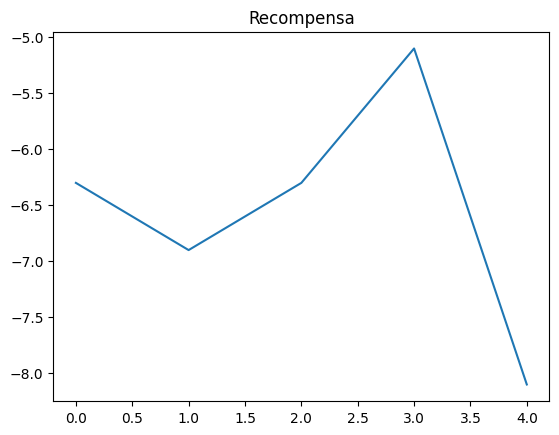

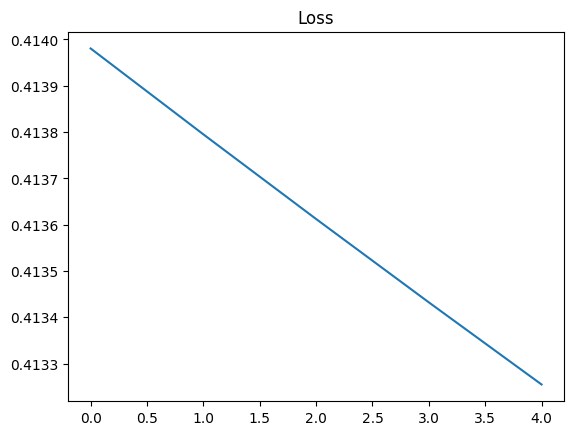

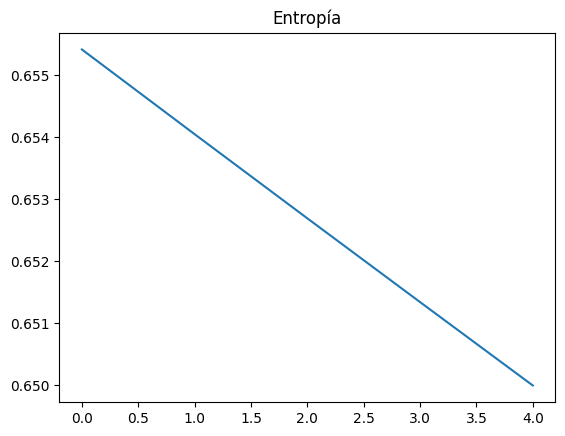

In [9]:
modelo_entrenado = "4"
PPO = PPO_Clip(hiperparams, device )
rewards, loss, entropy = PPO.train(env, save_file_policy=f"trained_net/{modelo_entrenado}/flappy_actor.pth", save_file_value=f"trained_net/{modelo_entrenado}/flappy_critic.pth")
plt.plot(rewards)
plt.title("Recompensa")
plt.savefig(f"trained_net/{modelo_entrenado}/recompensa.png")
plt.show()

plt.plot(loss)
plt.title("Loss")
plt.savefig(f"trained_net/{modelo_entrenado}/loss.png")
plt.show()  

plt.plot(entropy)
plt.title("Entropía")
plt.savefig(f"trained_net/{modelo_entrenado}/entropy.png")
plt.show()

#guardar figuras

In [ ]:
modelo_entrenado = "4"
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
PPO = PPO_Clip(hiperparams, device )

policy_net = PolicyNet(12, 2)
policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth", map_location=device))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 5)
env.close()

reward: 68.90000000000022 en 574 pasos
reward: 17.90000000000001 en 163 pasos
reward: 12.899999999999974 en 122 pasos
reward: 4.999999999999995 en 61 pasos


KeyboardInterrupt: 

: 